# Plugging a Custom CI Test into causal-ts

causal-ts is designed so that any conditional-independence test can be registered in three steps:

1. **Subclass `CIT_Base`** — the shared base every built-in test uses (caching, NaN
   handling, sample-size bookkeeping).
2. **Implement `__call__(self, X, Y, condition_set=None)`** — return `(p_value, test_statistic)`.
3. **Decorate with `@register_ci_test("name")`** — makes the test available to
   `list_ci_tests()`, `create_ci_test()`, and the `causal-ts discover --ci-test name` CLI.

This notebook walks through a complete worked example: a **Spearman partial-correlation**
test — partial correlation computed on rank-transformed data, which catches monotone
nonlinear relationships that plain (Pearson) partial correlation misses.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from scipy import stats

from causalts.ci_tests import register_ci_test, create_ci_test, list_ci_tests
from causalts.ci_tests.cit_test import CIT_Base
from causalts.ci_tests import ParCorrGPU
from causalts import run_cdnots
from causalts.utils import evaluate_graph
import causalts.plotting as tp

print("Before registration:", list_ci_tests())

Before registration: ['chisq', 'cmiknn', 'cmiknn-gpu', 'cmiknn-mixed-gpu', 'dfcit', 'fisherz', 'gcmi', 'gsquared', 'kci', 'parcorr', 'parcorr-gpu', 'rcot', 'sigkci', 'splitkci']


## Step 1 — Implement `__call__`

Subclass `CIT_Base` and implement the test interface: given two column indices and an
optional list of conditioning-column indices, return `(p_value, test_statistic)`.
`CIT_Base.__init__` stores `data` as a NumPy array and handles caching — call
`super().__init__(data=data, method=...)` and you get that for free.

In [2]:
class SpearmanCIT(CIT_Base):
    """Partial correlation computed on rank-transformed data.

    Rank-transforming before computing (partial) correlation turns any
    monotone relationship into a linear one, so this catches monotone
    nonlinear dependence (e.g. exp, log) that a Pearson-based test misses,
    at the cost of missing non-monotone dependence (e.g. a symmetric
    U-shape) that a Pearson-based test would also miss anyway.
    """

    def __init__(self, data, **kwargs):
        super().__init__(data=data, method="spearman", **kwargs)

    def __call__(self, X, Y, condition_set=None):
        if condition_set is None:
            condition_set = []
        data = self.data
        x = stats.rankdata(data[:, X])
        y = stats.rankdata(data[:, Y])
        n = len(x)

        if len(condition_set) == 0:
            r, _ = stats.pearsonr(x, y)
            dof = n - 2
        else:
            z = np.column_stack([stats.rankdata(data[:, c]) for c in condition_set])
            z = np.column_stack([z, np.ones(n)])  # intercept
            beta_x, *_ = np.linalg.lstsq(z, x, rcond=None)
            beta_y, *_ = np.linalg.lstsq(z, y, rcond=None)
            resid_x = x - z @ beta_x
            resid_y = y - z @ beta_y
            r, _ = stats.pearsonr(resid_x, resid_y)
            dof = n - 2 - len(condition_set)

        r = np.clip(r, -0.999999, 0.999999)
        t_stat = r * np.sqrt(dof / (1 - r**2))
        p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=dof))
        return p_value, r

## Step 2 — Register with `@register_ci_test`

`register_ci_test("name")` is a decorator that stores the class under that name.
It can be applied at class-definition time (`@register_ci_test("spearman")` directly
above `class SpearmanCIT`) or, as shown here, applied afterwards — it's just a
function that returns a decorator, so `register_ci_test("spearman")(SpearmanCIT)`
does the same thing.

In [3]:
SpearmanCIT = register_ci_test("spearman")(SpearmanCIT)

print("After registration:", list_ci_tests())

After registration: ['chisq', 'cmiknn', 'cmiknn-gpu', 'cmiknn-mixed-gpu', 'dfcit', 'fisherz', 'gcmi', 'gsquared', 'kci', 'parcorr', 'parcorr-gpu', 'rcot', 'sigkci', 'spearman', 'splitkci']


## Step 3 — Use it directly

Once registered, `create_ci_test` instantiates it by name like any built-in test.

In [4]:
# A small synthetic system: X0(t-1) -> X1(t) is monotone nonlinear (exp),
# X1(t-1) -> X2(t) is linear.
rng = np.random.default_rng(42)
T = 400
x0 = rng.standard_normal(T)
x1 = np.zeros(T)
x2 = np.zeros(T)
for t in range(1, T):
    x1[t] = np.exp(0.6 * x0[t - 1]) + 0.4 * rng.standard_normal()
    x2[t] = 0.6 * x1[t - 1] + 0.3 * rng.standard_normal()
df = pd.DataFrame({"X0": x0, "X1": x1, "X2": x2})

d, max_lag = 3, 1
gt = np.zeros((d, d, max_lag + 1), dtype=np.int8)
gt[0, 1, 1] = 1  # X0(t-1) -> X1(t)
gt[1, 2, 1] = 1  # X1(t-1) -> X2(t)

ci = create_ci_test("spearman", df.values)
p, stat = ci(0, 1)
print(f"X0 _|_ X1 (unconditional): p={p:.4f}, r={stat:.4f}")

X0 _|_ X1 (unconditional): p=0.0617, r=0.0935


## Step 4 — Run a discovery algorithm with it

Any registered CI test can be passed straight into `run_cdnots` (or `run_cdnots_plus`,
`run_cedar`, ...) as `indep_test` — the algorithms only depend on the `__call__`
interface, not on which class implements it.

In [5]:
res_spearman = run_cdnots(
    df=df, indep_test=create_ci_test("spearman", df.values),
    num_lags=1, include_C=False, alpha=0.05,
)
m_spearman = evaluate_graph(res_spearman.cg_tig, gt)
print(f"Spearman  F1={m_spearman['F1']:.3f}  Precision={m_spearman['Precision']:.3f}  "
      f"Recall={m_spearman['TPR']:.3f}  SHD={m_spearman['SHD']}")

Spearman  F1=1.000  Precision=1.000  Recall=1.000  SHD=0


## Step 5 — Compare against a built-in test

Same data, same algorithm, only the CI test differs. `ParCorrGPU` (Pearson partial
correlation) treats the exponential `X0 -> X1` relationship as noisier than it is,
since Pearson correlation only sees the linear component of a monotone-but-curved
relationship — this can cost precision even though the true edge is still detected.

ParCorr   F1=0.667  Precision=0.500  Recall=1.000  SHD=2


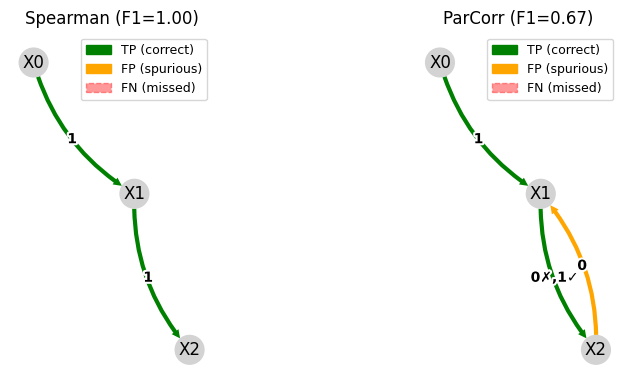

In [6]:
res_parcorr = run_cdnots(
    df=df, indep_test=ParCorrGPU(df.values.astype(np.float32), device="cpu"),
    num_lags=1, include_C=False, alpha=0.05,
)
m_parcorr = evaluate_graph(res_parcorr.cg_tig, gt)
print(f"ParCorr   F1={m_parcorr['F1']:.3f}  Precision={m_parcorr['Precision']:.3f}  "
      f"Recall={m_parcorr['TPR']:.3f}  SHD={m_parcorr['SHD']}")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
tp.compare_graphs(
    gt, res_spearman.cg_tig, var_names=list(df.columns),
    fig_ax=(fig, axes[0]), legend_loc=None, node_size=0.2, arrow_linewidth=3,
)
axes[0].set_title(f"Spearman (F1={m_spearman['F1']:.2f})", fontsize=12)
tp.compare_graphs(
    gt, res_parcorr.cg_tig, var_names=list(df.columns),
    fig_ax=(fig, axes[1]), legend_loc=None, node_size=0.2, arrow_linewidth=3,
)
axes[1].set_title(f"ParCorr (F1={m_parcorr['F1']:.2f})", fontsize=12)
plt.tight_layout()
plt.show()

## Step 6 — CLI integration

Once your module is imported, the CLI picks up your CI test automatically.
No edits to causal-ts source code are required.

```python
# my_spearman_plugin.py
from causalts.ci_tests import register_ci_test
from causalts.ci_tests.cit_test import CIT_Base
...
@register_ci_test("spearman")
class SpearmanCIT(CIT_Base): ...
```

```bash
# In an environment where your module is importable:
causal-ts discover data.csv --algorithm cdnots --ci-test spearman --max-lag 3
```

Or from Python:

```python
from causalts.ci_tests import create_ci_test
import my_spearman_plugin  # triggers registration

ci = create_ci_test("spearman", df.values)
```

## Summary — Minimal interface checklist

To integrate any conditional-independence test:

```python
from causalts.ci_tests import register_ci_test
from causalts.ci_tests.cit_test import CIT_Base

@register_ci_test("my_test")
class MyCITest(CIT_Base):
    def __init__(self, data, **kwargs):
        super().__init__(data=data, method="my_test", **kwargs)

    def __call__(self, X, Y, condition_set=None):
        # ... your test logic ...
        return p_value, test_statistic
```

**Inherited for free:**
- `self.data`, `self.sample_size`, `self.num_features` — set from the array passed in
- `cache_dir=` — on-disk p-value caching keyed by data hash and test parameters
- NaN detection (`self._has_nan`) — built-ins use this to fall back to pairwise-complete rows
- `list_ci_tests()` / `create_ci_test("my_test", data)` — discoverable everywhere
- `causal-ts discover --ci-test my_test data.csv` — CLI
- Drop-in compatibility with every discovery algorithm's `indep_test=` parameter

**Optional overrides:**
- `seed=` — pass a fixed seed to `CIT_Base.__init__` for any test that samples internally
- `min_samples=` — raise/lower the pairwise-complete-rows floor for NaN handling
- A custom `__repr__` or additional constructor kwargs (e.g. a bandwidth, a kernel choice)